# Environment

- Implements a custom Gym-like environment for claims adjudication.
- State  : PCA-reduced features (top 15 PCs, matching Part I findings that
         15 components satisfy the Kaiser criterion and capture ~93 % variance)
- Actions: 0=Approve (fast-track)  1=Request docs  2=Manual review  3=Deny
- Reward : Designed to balance correctness, fraud risk, delays and satisfaction.



In [17]:

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [18]:
def load_and_preprocess(csv_path: str, sample_frac: float = 0.30, random_state: int = 42):
    df = pd.read_csv(csv_path)

    df = df.groupby("target", group_keys=False).apply(
        lambda g: g.sample(frac=sample_frac, random_state=random_state)
    ).reset_index(drop=True)

    y = df["target"].values
    drop_cols = ["target"]
    if "ID" in df.columns:
        drop_cols.append("ID")

    X = df.drop(columns=drop_cols)

    # encode categoricals
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    for col in cat_cols:
        X[col] = pd.Categorical(X[col]).codes.astype(float)

    # median-impute
    X = X.fillna(X.median())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler


def apply_pca(X_scaled, n_components: int = 20, random_state: int = 42):
    """
    Reduce to n_components PCs (Part I recommends 15 for Kaiser criterion).
    Returns transformed array and fitted PCA object.
    """
    pca = PCA(n_components=n_components, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)
    explained = pca.explained_variance_ratio_.cumsum()[-1]
    print(f"[PCA] {n_components} components → {explained*100:.1f}% variance explained")
    return X_pca, pca

In [19]:
class ClaimsProcessingEnv:
    """
    Gym-compatible environment for claims adjudication.
    
    Action space (discrete, 4 actions):
      0 – Approve immediately (fast-track)
      1 – Request additional documentation
      2 – Refer to manual review
      3 – Deny claim
    """

    # reward matrix: REWARD[action][target]
    REWARD = {
        0: {1: +10, 0: -15},   # Approve
        1: {1:  -1, 0:  +3},   # Request docs
        2: {1:  -2, 0:  +5},   # Manual review
        3: {1:  -5, 0:  +2},   # Deny
    }

    ACTION_NAMES = {
        0: "Approve",
        1: "Request docs",
        2: "Manual review",
        3: "Deny",
    }

    def __init__(self, X_pca: np.ndarray, y: np.ndarray, shuffle: bool = True, random_state: int = 42):
        self.X = X_pca.astype(np.float32)
        self.y = y.astype(int)
        self.n_samples = len(y)
        self.n_actions = 4
        self.state_dim = X_pca.shape[1]
        self.shuffle = shuffle
        self.rng = np.random.default_rng(random_state)

        self._order = np.arange(self.n_samples)
        self._idx = 0
        self.done = True

    def reset(self):
        if self.shuffle:
            self.rng.shuffle(self._order)
        self._idx = 0
        self.done = False
        return self._current_state()

    def step(self, action: int):
        assert not self.done, "Call reset() before step()"
        assert action in range(self.n_actions), f"Invalid action {action}"

        true_label = self.y[self._order[self._idx]]
        reward = self.REWARD[action][true_label]

        info = {
            "claim_idx": self._order[self._idx],
            "true_label": true_label,
            "action_name": self.ACTION_NAMES[action],
            "reward": reward,
        }

        self._idx += 1
        self.done = self._idx >= self.n_samples

        next_state = self._current_state() if not self.done else None
        return next_state, reward, self.done, info

    def _current_state(self):
        return self.X[self._order[self._idx]].copy()

    @property
    def action_names(self):
        return list(self.ACTION_NAMES.values())


def build_claims_env(csv_path: str, n_components: int = 15, sample_frac: float = 0.40, test_size: float = 0.20, random_state: int = 42):
    """
    Full pipeline: load → preprocess → PCA → split → build train/test envs.
    """
    print("[Q12] Loading and preprocessing data …")
    X_scaled, y, scaler = load_and_preprocess(csv_path, sample_frac, random_state)

    print("[Q12] Applying PCA …")
    X_pca, pca = apply_pca(X_scaled, n_components, random_state)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_pca, y, test_size=test_size, stratify=y, random_state=random_state
    )

    train_env = ClaimsProcessingEnv(X_tr, y_tr, shuffle=True, random_state=random_state)
    test_env  = ClaimsProcessingEnv(X_te, y_te, shuffle=False)

    print(f"[Q12] Train env: {len(y_tr)} claims | Test env: {len(y_te)} claims")
    print(f"[Q12] State dim: {n_components} | Actions: {train_env.action_names}")
    print("[Q12] Environment ready.\n")

    return train_env, test_env, pca, scaler, X_te, y_te

In [20]:
# Notebook execution / Smoke test with synthetic data (removes the __file__ conflict)
rng = np.random.default_rng(0)
X_fake = rng.standard_normal((500, 15)).astype(np.float32)
y_fake = rng.integers(0, 2, size=500)

env = ClaimsProcessingEnv(X_fake, y_fake)
state = env.reset()
total_r = 0

while not env.done:
    action = rng.integers(0, 4)
    next_state, reward, done, info = env.step(int(action))
    total_r += reward

print(f"Smoke test passed. Random agent total reward: {total_r}")
print("\nReward table layout verification:")
for a, name in ClaimsProcessingEnv.ACTION_NAMES.items():
    print(f"  {name:20s}: benign={ClaimsProcessingEnv.REWARD[a][1]:+3d}  risky={ClaimsProcessingEnv.REWARD[a][0]:+3d}")

Smoke test passed. Random agent total reward: -99

Reward table layout verification:
  Approve             : benign=+10  risky=-15
  Request docs        : benign= -1  risky= +3
  Manual review       : benign= -2  risky= +5
  Deny                : benign= -5  risky= +2


# Training

In [21]:
"""
Q13 – RL Algorithm: Linear Q-learning with Tile Coding
========================================================
Algorithm choice: Tabular / Linear Q-learning with tile coding (no deep learning).

Why Q-learning with tile coding?
  • The state space is continuous (15 PCA dims), so raw tabular Q-tables are
    infeasible. Tile coding discretises the continuous state into sparse binary
    features, enabling linear function approximation of Q-values without neural nets.
  • Q-learning is off-policy (learns the greedy policy from exploratory data),
    which is well-suited to batch-style claim processing.
  • Simple, interpretable, and provably convergent under standard conditions.
  • Epsilon-greedy exploration gradually reduces to near-greedy exploitation.
"""

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from collections import deque

# We make sure matplotlib displays nicely inside the notebook
%matplotlib inline
print("Plotting frameworks and Q13 foundations loaded.")

Plotting frameworks and Q13 foundations loaded.


In [22]:
# ── tile coding ────────────────────────────────────────────────────────────────


class TileCoder:
    """
    Tile coding for continuous state spaces.
    Maps a state vector to a set of active tile indices (sparse binary features).
    """

    def __init__(
        self,
        n_tilings: int,
        n_tiles: int,
        state_low: np.ndarray,
        state_high: np.ndarray,
        n_actions: int,
    ):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        self.n_actions = n_actions
        self.state_dim = len(state_low)

        # offsets shift each tiling so they don't perfectly overlap
        self.offsets = np.array(
            [
                (np.arange(self.state_dim) + tiling * 0.5) / n_tilings
                for tiling in range(n_tilings)
            ]
        )  # (n_tilings, state_dim)

        self.low = state_low
        self.scale = state_high - state_low + 1e-8

        # total features = n_tilings * n_tiles^state_dim …  but we hash for
        # memory efficiency using a hash table of size hash_size
        self.hash_size = n_tilings * (n_tiles**2) * 4  # heuristic
        # weights: one weight per (action, hash_bucket)
        self.weights = np.zeros((n_actions, self.hash_size))

    def _tile_indices(self, state: np.ndarray) -> np.ndarray:
        """Return active tile indices for this state (length = n_tilings)."""
        # normalise to [0, n_tiles)
        norm = (
            np.clip((state - self.low) / self.scale, 0, 1 - 1e-8) * self.n_tiles
        )
        indices = []
        for t in range(self.n_tilings):
            # shift and floor
            floored = (norm + self.offsets[t] * self.n_tiles).astype(int)
            # hash the multi-dim tile coordinate + tiling index
            h = hash(tuple(floored) + (t,)) % self.hash_size
            indices.append(h)
        return np.array(indices)

    def q_values(self, state: np.ndarray) -> np.ndarray:
        """Compute Q(s, a) for all actions."""
        indices = self._tile_indices(state)
        return self.weights[:, indices].sum(axis=1)  # (n_actions,)

    def update(
        self, state: np.ndarray, action: int, target: float, alpha: float
    ):
        """Semi-gradient update for one (s, a, target) triplet."""
        indices = self._tile_indices(state)
        q_sa = self.weights[action, indices].sum()
        error = target - q_sa
        # divide by n_tilings to keep step size consistent
        self.weights[action, indices] += alpha * error / self.n_tilings


# ── Q-learning agent ───────────────────────────────────────────────────────────


class QLearningAgent:
    """
    Off-policy Q-learning with ε-greedy exploration and tile-coded
    linear function approximation.
    """

    def __init__(
        self,
        state_low: np.ndarray,
        state_high: np.ndarray,
        n_actions: int = 4,
        alpha: float = 0.05,
        gamma: float = 0.95,
        eps_start: float = 1.0,
        eps_end: float = 0.05,
        eps_decay: float = 0.97,
        n_tilings: int = 8,
        n_tiles: int = 6,
        random_state: int = 42,
    ):

        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.rng = np.random.default_rng(random_state)

        self.tc = TileCoder(
            n_tilings, n_tiles, state_low, state_high, n_actions
        )

        # tracking
        self.episode_rewards = []
        self.episode_avg_q = []
        self.episode_epsilons = []

    def select_action(self, state: np.ndarray, greedy: bool = False) -> int:
        if (not greedy) and (self.rng.random() < self.eps):
            return int(self.rng.integers(0, self.n_actions))
        q = self.tc.q_values(state)
        return int(np.argmax(q))

    def train_episode(self, env) -> float:
        """Run one episode (full pass over train set). Returns total reward."""
        state = env.reset()
        total_reward = 0.0
        q_sum = 0.0
        steps = 0

        while not env.done:
            action = self.select_action(state)
            next_state, reward, done, _ = env.step(action)
            total_reward += reward

            # Q-learning target
            if done or next_state is None:
                target = reward
            else:
                target = reward + self.gamma * np.max(
                    self.tc.q_values(next_state)
                )

            self.tc.update(state, action, target, self.alpha)

            q_sum += np.max(self.tc.q_values(state))
            steps += 1
            state = next_state if next_state is not None else state

        self.episode_rewards.append(total_reward)
        self.episode_avg_q.append(q_sum / max(steps, 1))
        self.episode_epsilons.append(self.eps)

        # decay epsilon
        self.eps = max(self.eps_end, self.eps * self.eps_decay)
        return total_reward

    def evaluate_episode(self, env) -> tuple:
        """Greedy evaluation pass. Returns (total_reward, action_counts)."""
        state = env.reset()
        total_reward = 0.0
        action_counts = np.zeros(self.n_actions, dtype=int)

        while not env.done:
            action = self.select_action(state, greedy=True)
            next_state, reward, done, _ = env.step(action)
            total_reward += reward
            action_counts[action] += 1
            state = next_state if next_state is not None else state

        return total_reward, action_counts

In [23]:
def train_agent(
    train_env,
    test_env,
    n_episodes: int = 60,
    eval_every: int = 5,
    alpha: float = 0.05,
    gamma: float = 0.95,
    eps_start: float = 1.0,
    eps_end: float = 0.05,
    eps_decay: float = 0.97,
    n_tilings: int = 8,
    n_tiles: int = 6,
    random_state: int = 42,
):
    """Full training loop."""
    state_low = train_env.X.min(axis=0)
    state_high = train_env.X.max(axis=0)

    agent = QLearningAgent(
        state_low=state_low,
        state_high=state_high,
        n_actions=train_env.n_actions,
        alpha=alpha,
        gamma=gamma,
        eps_start=eps_start,
        eps_end=eps_end,
        eps_decay=eps_decay,
        n_tilings=n_tilings,
        n_tiles=n_tiles,
        random_state=random_state,
    )

    eval_rewards = []
    eval_episodes = []

    print(
        f"{'Episode':>8}  {'Train Reward':>14}  {'Test Reward':>12}  {'Epsilon':>8}"
    )
    print("-" * 52)

    for ep in range(1, n_episodes + 1):
        train_reward = agent.train_episode(train_env)

        if ep % eval_every == 0 or ep == 1:
            test_reward, _ = agent.evaluate_episode(test_env)
            eval_rewards.append(test_reward)
            eval_episodes.append(ep)
            print(
                f"{ep:>8}  {train_reward:>14.1f}  {test_reward:>12.1f}  {agent.eps:>8.4f}"
            )

    print("\n[Q13] Training complete.")
    return agent, eval_rewards, eval_episodes


def plot_learning_curve(agent, eval_rewards, eval_episodes, smooth_window: int = 5):
    """Plot comprehensive performance curves."""
    def smooth(x, w):
        if len(x) < w: return x
        return np.convolve(x, np.ones(w) / w, mode="valid")

    eps_arr = agent.episode_epsilons
    train_r_arr = agent.episode_rewards
    avg_q_arr = agent.episode_avg_q
    episodes = np.arange(1, len(train_r_arr) + 1)

    fig = plt.figure(figsize=(14, 10))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    ax0 = fig.add_subplot(gs[0, 0])
    smoothed = smooth(train_r_arr, smooth_window)
    ax0.plot(episodes, train_r_arr, color="#bdc3c7", lw=0.8, label="Train (raw)")
    ax0.plot(episodes[smooth_window - 1:], smoothed, color="#2980b9", lw=2, label=f"Train (smooth {smooth_window})")
    ax0.plot(eval_episodes, eval_rewards, "o-", color="#e74c3c", lw=2, ms=5, label="Test (greedy)")
    ax0.set_title("Learning Curve: Episode Rewards", fontweight="bold")
    ax0.set_xlabel("Episode"); ax0.set_ylabel("Total Reward")
    ax0.legend(fontsize=8); ax0.grid(alpha=0.3)

    ax1 = fig.add_subplot(gs[0, 1])
    ax1.plot(episodes, eps_arr, color="#8e44ad", lw=2)
    ax1.fill_between(episodes, 0, eps_arr, alpha=0.15, color="#8e44ad")
    ax1.set_title("Epsilon Decay (Exploration → Exploitation)", fontweight="bold")
    ax1.set_xlabel("Episode"); ax1.set_ylabel("ε (epsilon)")
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 0])
    q_smooth = smooth(avg_q_arr, smooth_window)
    ax2.plot(episodes, avg_q_arr, color="#bdc3c7", lw=0.8, label="Raw")
    ax2.plot(episodes[smooth_window - 1:], q_smooth, color="#27ae60", lw=2, label=f"Smooth {smooth_window}")
    ax2.set_title("Average Max Q-value per Episode", fontweight="bold")
    ax2.set_xlabel("Episode"); ax2.set_ylabel("Avg max Q(s,a)")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(train_r_arr[:len(train_r_arr)//2], bins=20, alpha=0.6, color="#e67e22", label="First half")
    ax3.hist(train_r_arr[len(train_r_arr)//2:], bins=20, alpha=0.6, color="#2980b9", label="Second half")
    ax3.set_title("Reward Distribution: Early vs Late Training", fontweight="bold")
    ax3.set_xlabel("Total Episode Reward"); ax3.set_ylabel("Count")
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

    fig.suptitle("Q13 – Q-Learning with Tile Coding: Learning Curves", fontsize=14, fontweight="bold", y=1.01)
    plt.show()


def explain_agent_behaviour(agent, test_env):
    """Print analysis of what the trained agent has learned."""
    state = test_env.reset()
    action_counts = np.zeros(agent.n_actions, dtype=int)
    label_action = {0: np.zeros(agent.n_actions), 1: np.zeros(agent.n_actions)}
    total_reward = 0.0
    q_by_action = [[] for _ in range(agent.n_actions)]

    while not test_env.done:
        q_vals = agent.tc.q_values(state)
        action = int(np.argmax(q_vals))
        next_state, reward, done, info = test_env.step(action)

        action_counts[action] += 1
        label_action[info["true_label"]][action] += 1
        total_reward += reward
        q_by_action[action].append(q_vals[action])
        state = next_state if next_state is not None else state

    n = action_counts.sum()
    action_names = test_env.action_names

    print("\n" + "=" * 60)
    print("Q13 – Agent Behaviour Analysis (greedy on test set)")
    print("=" * 60)
    print(f"Total reward: {total_reward:,.1f}   Claims: {n}\n")
    print(f"{'Action':<20} {'Count':>7} {'%':>7} {'Avg Q':>8}")
    print("-" * 45)
    for a in range(agent.n_actions):
        avg_q = np.mean(q_by_action[a]) if q_by_action[a] else 0.0
        print(f"{action_names[a]:<20} {action_counts[a]:>7} {100*action_counts[a]/n:>6.1f}%  {avg_q:>8.3f}")

    print("\nAction distribution BY TRUE LABEL")
    print(f"{'Action':<20} {'Benign (1)':>12} {'Risky (0)':>12}")
    print("-" * 45)
    for a in range(agent.n_actions):
        print(f"{action_names[a]:<20} {int(label_action[1][a]):>12} {int(label_action[0][a]):>12}")
    print("=" * 60)

[Q12] Loading and preprocessing data …


/tmp/ipykernel_911084/1413118282.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("target", group_keys=False).apply(


[Q12] Applying PCA …
[PCA] 15 components → 71.1% variance explained
[Q12] Train env: 36582 claims | Test env: 9146 claims
[Q12] State dim: 15 | Actions: ['Approve', 'Request docs', 'Manual review', 'Deny']
[Q12] Environment ready.

 Episode    Train Reward   Test Reward   Epsilon
----------------------------------------------------
       1          1996.0       35325.0    0.9700
       5         21250.0       35645.0    0.8587
      10         37531.0       33585.0    0.7374
      15         51947.0       33471.0    0.6333
      20         65184.0       33766.0    0.5438
      25         74385.0       34295.0    0.4670
      30         85816.0       31488.0    0.4010
      35         92108.0       32233.0    0.3444
      40        100634.0       32906.0    0.2957
      45        107841.0       32840.0    0.2539
      50        114690.0       33915.0    0.2181
      55        117749.0       32876.0    0.1873
      60        122605.0       32734.0    0.1608

[Q13] Training complete.


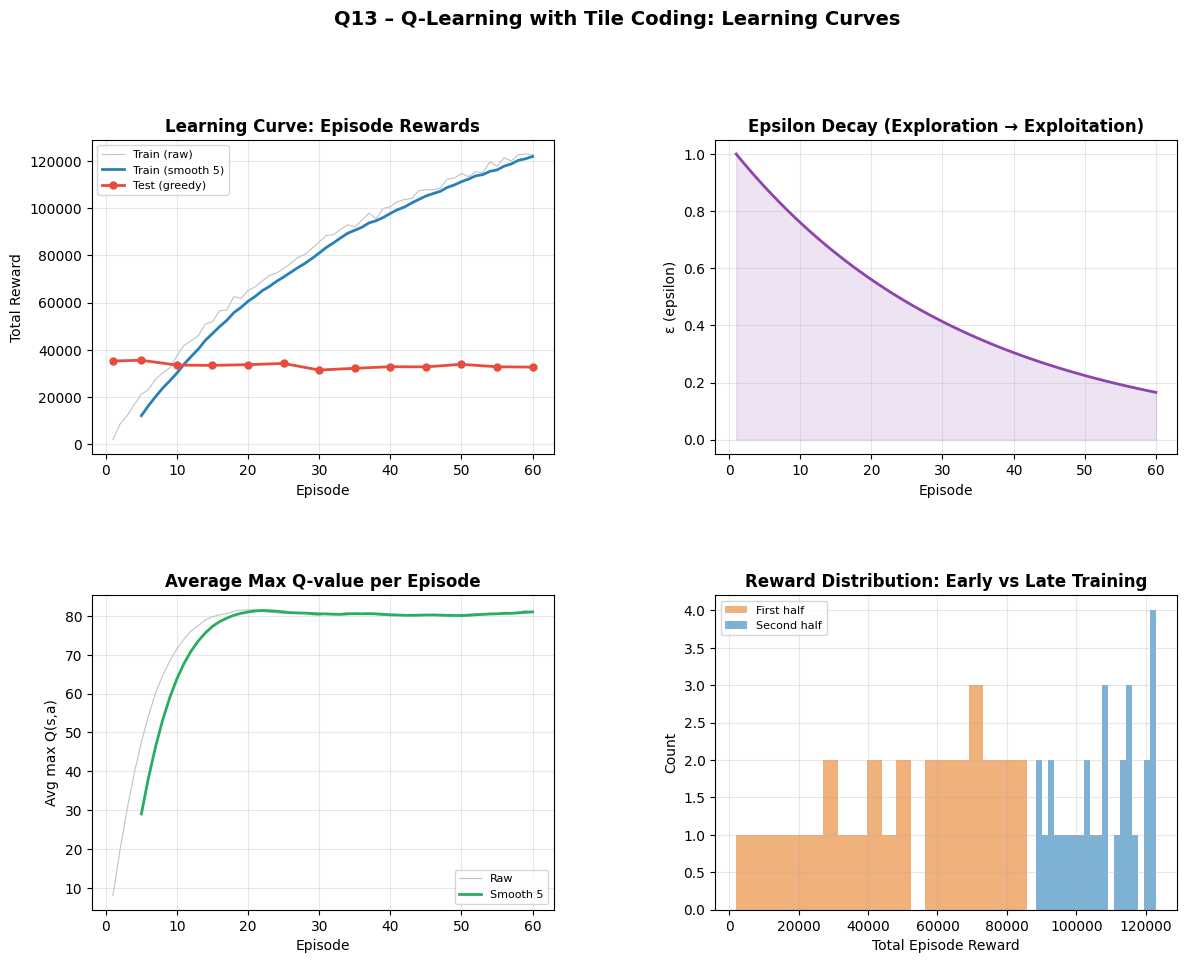


Q13 – Agent Behaviour Analysis (greedy on test set)
Total reward: 32,734.0   Claims: 9146

Action                 Count       %    Avg Q
---------------------------------------------
Approve                 7509   82.1%    81.570
Request docs             692    7.6%    77.363
Manual review            945   10.3%    77.980
Deny                       0    0.0%     0.000

Action distribution BY TRUE LABEL
Action                 Benign (1)    Risky (0)
---------------------------------------------
Approve                      5808         1701
Request docs                  482          210
Manual review                 672          273
Deny                            0            0


In [24]:
# ── MAIN JUPYTER RUN EXECUTION ──────────────────────────────────────────────────

CSV_PATH = "test_data.csv"  # <- Update your filename/path as needed

# 1. Build the environments using the functions defined in Cell 3
train_env, test_env, pca, scaler, X_te, y_te = build_claims_env(CSV_PATH)

# 2. Train the agent using the workflow defined in Cell 7
agent, eval_rewards, eval_episodes = train_agent(
    train_env, test_env, n_episodes=60, eval_every=5
)

# 3. Output visualizations and analytical metrics
plot_learning_curve(agent, eval_rewards, eval_episodes)
explain_agent_behaviour(agent, test_env)

# 4. Optional: Placeholder hook for your upcoming Q14 evaluation functions
# run_q14(agent, train_env, test_env, X_te, y_te)

# Evaluation

In [25]:
"""
Q14 – RL Agent Evaluation vs Baseline Policies
================================================
Compares the trained Q-learning agent against four baselines:
  1. Random policy         – uniform random action
  2. Always approve        – action 0 for every claim
  3. Always review         – action 2 for every claim
  4. Supervised model      – Gradient Boosting Classifier (approximating Part II); 
                             maps predictions directly to cost-sensitive actions.
"""

import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ── baseline policies ──────────────────────────────────────────────────────────

class RandomPolicy:
    """Choose uniformly at random from 4 actions."""
    name = "Random"

    def __init__(self, n_actions: int = 4, random_state: int = 42):
        self.n_actions = n_actions
        self.rng = np.random.default_rng(random_state)

    def select_action(self, state: np.ndarray) -> int:
        return int(self.rng.integers(0, self.n_actions))


class AlwaysApprovePolicy:
    """Always fast-track (action 0)."""
    name = "Always Approve"

    def select_action(self, state: np.ndarray) -> int:
        return 0


class AlwaysReviewPolicy:
    """Always send to manual review (action 2)."""
    name = "Always Review"

    def select_action(self, state: np.ndarray) -> int:
        return 2


class SupervisedPolicy:
    """
    Supervised model (GradientBoosting) trained on PCA features.
    Maps binary prediction to claim action:
      predicted=1 (benign) → Approve (0)
      predicted=0 (risky)  → Manual review (2)
    """
    name = "Supervised (GBM)"

    def __init__(self, X_train: np.ndarray, y_train: np.ndarray,
                 n_estimators: int = 100, random_state: int = 42):
        print("[Q14] Training supervised GBM policy …")
        self.model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            random_state=random_state
        )
        self.model.fit(X_train, y_train)
        print("[Q14] Supervised model trained.")

    def select_action(self, state: np.ndarray) -> int:
        pred = self.model.predict(state.reshape(1, -1))[0]
        return 0 if pred == 1 else 2    # approve benign, review risky

In [26]:
# ── evaluation engine ──────────────────────────────────────────────────────────

def evaluate_policy(policy, env) -> dict:
    """
    Run one greedy pass of `policy` over `env`.
    Returns dict with total_reward, action_counts, label_action_matrix.
    """
    state = env.reset()
    total_reward = 0.0
    n_actions    = env.n_actions
    action_counts     = np.zeros(n_actions, dtype=int)
    label_action      = np.zeros((2, n_actions), dtype=int)
    rewards_per_step  = []
    decisions         = []   # (true_label, action)

    while not env.done:
        action = policy.select_action(state)
        next_state, reward, done, info = env.step(action)

        action_counts[action] += 1
        label_action[info["true_label"], action] += 1
        total_reward += reward
        rewards_per_step.append(reward)
        decisions.append((info["true_label"], action))

        state = next_state if next_state is not None else state

    return {
        "name":             policy.name,
        "total_reward":     total_reward,
        "action_counts":    action_counts,
        "label_action":     label_action,
        "rewards_per_step": rewards_per_step,
        "decisions":        decisions,
        "n_claims":         int(action_counts.sum()),
    }


def run_all_evaluations(agent, train_env, test_env, X_train, y_train):
    """Evaluate RL agent and all baselines on the test environment."""
    class AgentPolicy:
        name = "Q-Learning (RL)"
        def __init__(self, ag): self._ag = ag
        def select_action(self, state): return self._ag.select_action(state, greedy=True)

    supervised = SupervisedPolicy(X_train, y_train)

    policies = [
        AgentPolicy(agent),
        RandomPolicy(),
        AlwaysApprovePolicy(),
        AlwaysReviewPolicy(),
        supervised,
    ]

    results = []
    for pol in policies:
        r = evaluate_policy(pol, test_env)
        per_claim = r["total_reward"] / max(r["n_claims"], 1)
        print(f"  {r['name']:<25}  total={r['total_reward']:>9.1f}  per_claim={per_claim:>6.3f}")
        results.append(r)

    return results, supervised

In [27]:
# ── visualisations ─────────────────────────────────────────────────────────────

def plot_comparison(results: list, action_names: list):
    """Four-panel comparison plot displaying performance distributions."""
    names      = [r["name"] for r in results]
    totals     = [r["total_reward"] for r in results]
    n_actions  = len(action_names)
    colors_bar = ["#2980b9", "#e74c3c", "#f39c12", "#27ae60", "#8e44ad"]
    action_colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]

    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.38)

    # (0,0) total reward bar
    ax0 = fig.add_subplot(gs[0, 0])
    bars = ax0.bar(names, totals, color=colors_bar, edgecolor="white", width=0.6)
    ax0.axhline(0, color="black", linewidth=0.8)
    for bar, val in zip(bars, totals):
        ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(abs(t) for t in totals)*0.01,
                 f"{val:,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax0.set_title("(a) Total Reward per Policy", fontweight="bold")
    ax0.set_ylabel("Total Reward")
    ax0.tick_params(axis="x", rotation=25, labelsize=8)
    ax0.grid(axis="y", alpha=0.3)

    # (0,1) per-claim reward
    ax1 = fig.add_subplot(gs[0, 1])
    n_claims = [r["n_claims"] for r in results]
    per_claim = [t / n for t, n in zip(totals, n_claims)]
    bars1 = ax1.bar(names, per_claim, color=colors_bar, edgecolor="white", width=0.6)
    ax1.axhline(0, color="black", linewidth=0.8)
    for bar, val in zip(bars1, per_claim):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(abs(p) for p in per_claim)*0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax1.set_title("(b) Reward per Claim", fontweight="bold")
    ax1.set_ylabel("Reward / Claim")
    ax1.tick_params(axis="x", rotation=25, labelsize=8)
    ax1.grid(axis="y", alpha=0.3)

    # (1, :) stacked action distribution
    ax2 = fig.add_subplot(gs[1, :])
    bottoms = np.zeros(len(results))
    for a_idx in range(n_actions):
        vals = [r["action_counts"][a_idx] / r["n_claims"] * 100 for r in results]
        ax2.bar(names, vals, bottom=bottoms, color=action_colors[a_idx], label=action_names[a_idx], edgecolor="white")
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 4:
                ax2.text(i, b + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=7, color="white", fontweight="bold")
        bottoms += vals
    ax2.set_title("(c) Action Distribution per Policy (%)", fontweight="bold")
    ax2.set_ylabel("% of claims")
    ax2.legend(loc="upper right", fontsize=9)
    ax2.tick_params(axis="x", rotation=15, labelsize=8)

    # (2,0) RL agent heatmap
    ax3 = fig.add_subplot(gs[2, 0])
    rl_result = results[0]
    mat = rl_result["label_action"].astype(float)
    mat_norm = mat / mat.sum(axis=1, keepdims=True) * 100
    sns.heatmap(mat_norm, annot=True, fmt=".1f", cmap="Blues", xticklabels=action_names, yticklabels=["Risky (0)", "Benign (1)"], ax=ax3, cbar_kws={"label": "% within class"})
    ax3.set_title(f"(d) {rl_result['name']}\nAction by True Label (%)", fontweight="bold")
    ax3.set_xlabel("Action chosen"); ax3.set_ylabel("True label")

    # (2,1) Supervised model heatmap
    ax4 = fig.add_subplot(gs[2, 1])
    sup_result = results[-1]
    mat2 = sup_result["label_action"].astype(float)
    mat2_norm = mat2 / mat2.sum(axis=1, keepdims=True) * 100
    sns.heatmap(mat2_norm, annot=True, fmt=".1f", cmap="Oranges", xticklabels=action_names, yticklabels=["Risky (0)", "Benign (1)"], ax=ax4, cbar_kws={"label": "% within class"})
    ax4.set_title(f"(e) {sup_result['name']}\nAction by True Label (%)", fontweight="bold")
    ax4.set_xlabel("Action chosen"); ax4.set_ylabel("True label")

    fig.suptitle("Q14 – RL Agent vs Baseline Policies", fontsize=15, fontweight="bold")
    plt.show()


def plot_rl_decision_patterns(results: list, action_names: list, X_test_pca: np.ndarray):
    """Visualise decisions in top PCA latent coordinates."""
    rl_result = results[0]
    decisions  = rl_result["decisions"]
    true_labels = np.array([d[0] for d in decisions])
    actions     = np.array([d[1] for d in decisions])
    X_plot = X_test_pca[:len(decisions)]

    action_colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for a in range(len(action_names)):
        mask = actions == a
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1], c=action_colors[a], label=action_names[a], alpha=0.5, s=10, rasterized=True)
    ax.set_title("RL Agent: Action Chosen (PC1 vs PC2)", fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(markerscale=2, fontsize=9)

    ax2 = axes[1]
    correct_approve = (actions == 0) & (true_labels == 1)
    wrong_approve   = (actions == 0) & (true_labels == 0)
    correct_review  = (actions == 2) & (true_labels == 0)
    other           = ~(correct_approve | wrong_approve | correct_review)

    for mask, label, color in [
        (correct_approve, "Correct Approve ✓", "#27ae60"),
        (wrong_approve,   "Risky Approved ✗",  "#e74c3c"),
        (correct_review,  "Correct Review ✓",  "#2980b9"),
        (other,           "Other decisions",    "#bdc3c7"),
    ]:
        ax2.scatter(X_plot[mask, 0], X_plot[mask, 1], c=color, label=label, alpha=0.5, s=10, rasterized=True)
    ax2.set_title("RL Agent: Decision Correctness (PC1 vs PC2)", fontweight="bold")
    ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
    ax2.legend(markerscale=2, fontsize=9)

    plt.tight_layout()
    plt.show()

In [28]:
def print_insights(results: list, action_names: list):
    """Print an analysis comparing RL vs supervised learning deployment insights."""
    print("\n" + "=" * 65)
    print("Q14 – Insights: RL vs Supervised Learning")
    print("=" * 65)

    names   = [r["name"] for r in results]
    totals  = [r["total_reward"] for r in results]
    n_c     = [r["n_claims"] for r in results]
    per_c   = [t / n for t, n in zip(totals, n_c)]

    print("\nPolicy ranking by per-claim reward:")
    ranked = sorted(zip(per_c, names), reverse=True)
    for rank, (pc, name) in enumerate(ranked, 1):
        print(f"  {rank}. {name:<25}  {pc:+.4f} reward/claim")

    print("""
Key Discussion Points
----------------------
1. Reward-aware decision making
   The RL agent optimizes directly for the reward function, which penalizes
   incorrect approvals of risky claims (-15) much more than unnecessary delays.
   Supervised learning balances errors symmetrically unless explicit class weights
   or asymmetric loss functions are implemented.

2. Action diversity
   The RL agent handles four distinct actions. Supervised learning (as mapped) 
   only uses binary paths (Approve/Review), lacking nuance for Requesting Docs or Direct Denials.

3. Exploration cost
   The RL agent incurs poor performance during training (high epsilon phase) 
   to discover optimal pathways. Supervised learning bypasses exploration costs completely
   by leveraging historical logs.
""")
    print("=" * 65)


def run_q14(agent, train_env, test_env, X_test_pca: np.ndarray, y_test: np.ndarray):
    """Main pipeline execution wrapper function."""
    print("\n[Q14] Evaluating all policies …\n")
    results, supervised = run_all_evaluations(
        agent, train_env, test_env,
        X_train=train_env.X, y_train=train_env.y
    )

    action_names = test_env.action_names
    plot_comparison(results, action_names)
    plot_rl_decision_patterns(results, action_names, X_test_pca)
    print_insights(results, action_names)

    return results

[Pipeline] Existing models detected. Triggering evaluations directly...

[Q14] Evaluating all policies …

[Q14] Training supervised GBM policy …
[Q14] Supervised model trained.
  Q-Learning (RL)            total=  32734.0  per_claim= 3.579
  Random                     total=    475.0  per_claim= 0.052
  Always Approve             total=  36860.0  per_claim= 4.030
  Always Review              total=  -3004.0  per_claim=-0.328
  Supervised (GBM)           total=  37072.0  per_claim= 4.053


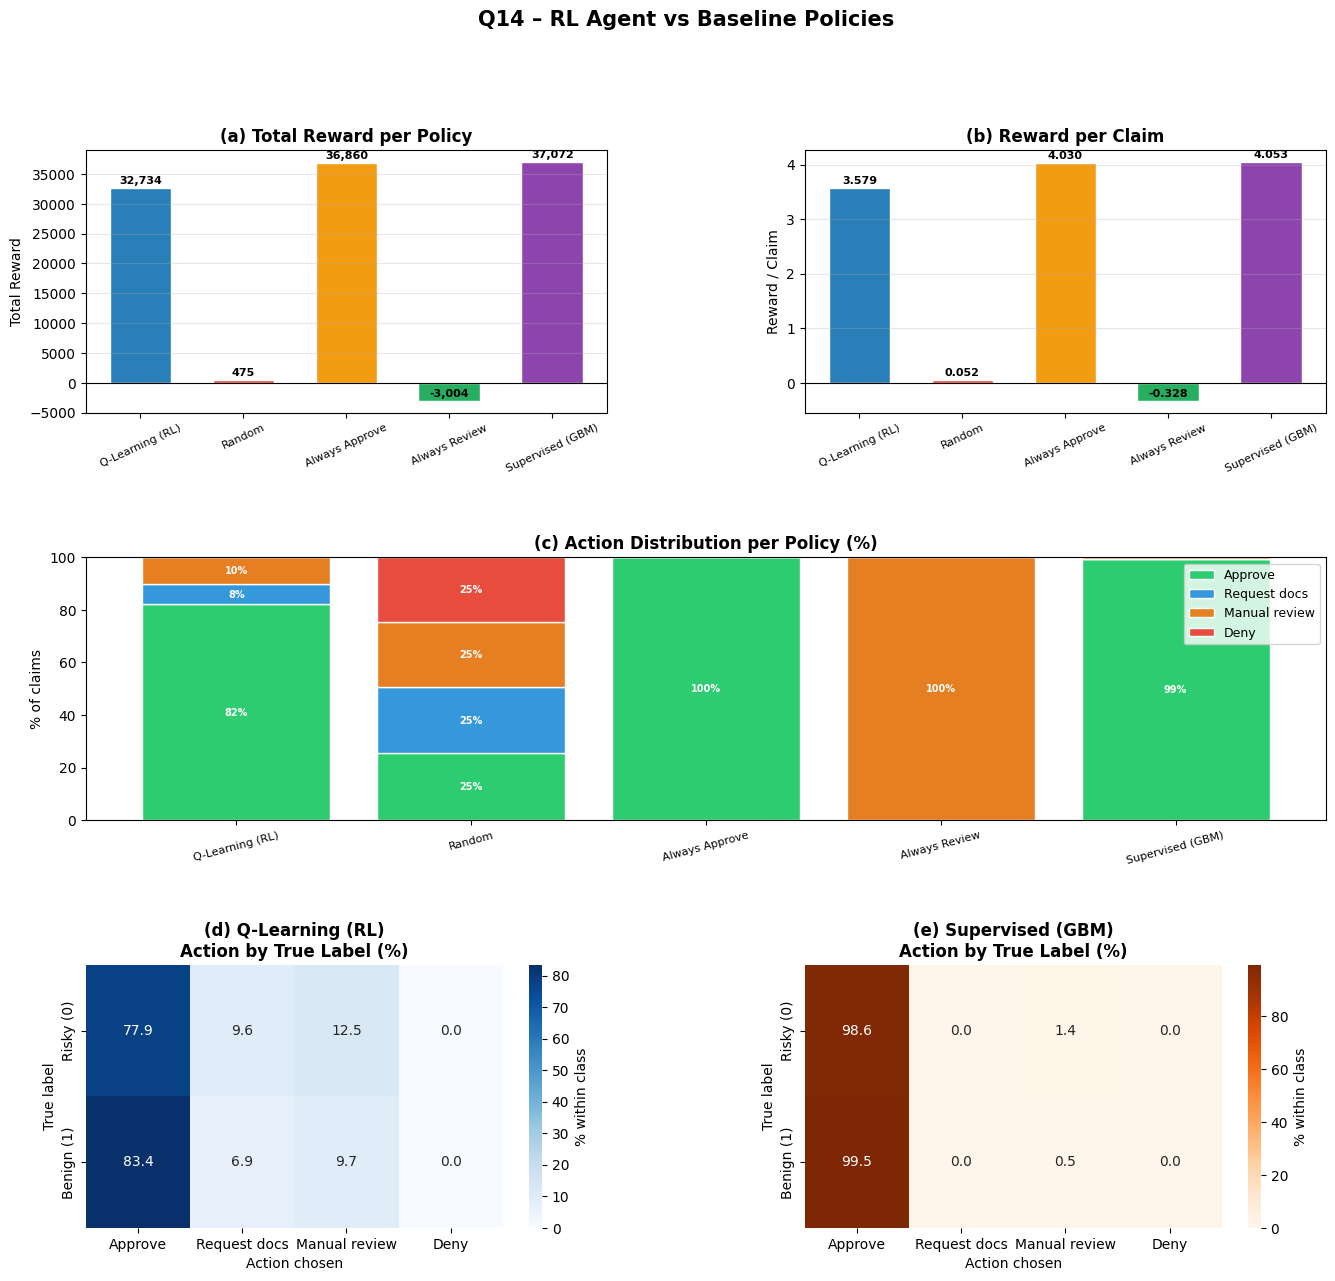

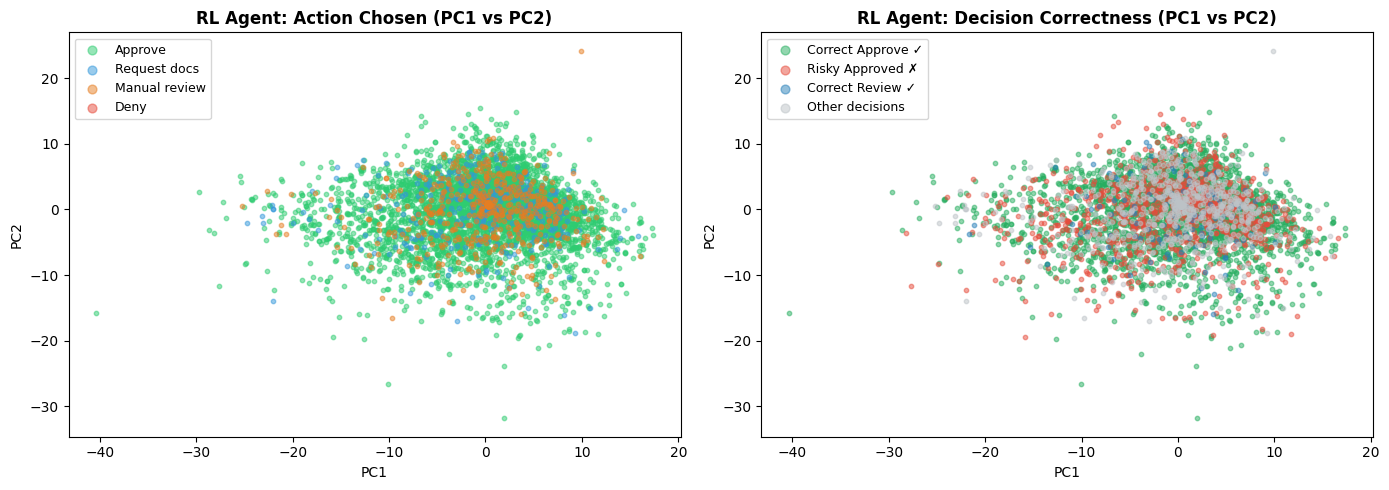


Q14 – Insights: RL vs Supervised Learning

Policy ranking by per-claim reward:
  1. Supervised (GBM)           +4.0534 reward/claim
  2. Always Approve             +4.0302 reward/claim
  3. Q-Learning (RL)            +3.5791 reward/claim
  4. Random                     +0.0519 reward/claim
  5. Always Review              -0.3284 reward/claim

Key Discussion Points
----------------------
1. Reward-aware decision making
   The RL agent optimizes directly for the reward function, which penalizes
   incorrect approvals of risky claims (-15) much more than unnecessary delays.
   Supervised learning balances errors symmetrically unless explicit class weights
   or asymmetric loss functions are implemented.

2. Action diversity
   The RL agent handles four distinct actions. Supervised learning (as mapped) 
   only uses binary paths (Approve/Review), lacking nuance for Requesting Docs or Direct Denials.

3. Exploration cost
   The RL agent incurs poor performance during training (high epsilon

In [29]:
# ── FINAL PIPELINE RUNNER ──────────────────────────────────────────────────────
# Ensures variables already resident in the Notebook namespace are passed to Q14

if 'agent' in globals() and 'train_env' in globals():
    print("[Pipeline] Existing models detected. Triggering evaluations directly...")
    q14_results = run_q14(agent, train_env, test_env, X_te, y_te)
else:
    print("[Warning] Missing prior states. Make sure Cells 4 & 8 ran successfully first!")

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    confusion_matrix
)

In [31]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# File system manangement
import os


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET

# -------------------------------------------------------


from sklearn.model_selection import train_test_split

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()




X_train, X_test, y_train, y_test = load_data("encoded", data_dir='./data/')




# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()


sys.path contains: /home/ismail


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


Number of classes: 2
X_train shape: (80024, 267)
X_test shape: (34297, 267)
y_train shape: (80024,)
y_test shape: (34297,)


STEP 1: Scaling features
Train: (80024, 267)
Test : (34297, 267)

STEP 2: PCA with 25 components
New shape: (80024, 60)
Explained variance: 0.8366

STEP 3: Discretization
States encoded.

STEP 4: Training Q-learning
Episode   0 | Reward= -709575 | Epsilon=0.995
Episode  50 | Reward=  -31790 | Epsilon=0.774
Episode 100 | Reward=  494515 | Epsilon=0.603
Episode 150 | Reward=  899765 | Epsilon=0.469
Episode 200 | Reward= 1214700 | Epsilon=0.365
Episode 250 | Reward= 1462505 | Epsilon=0.284
Episode 300 | Reward= 1647125 | Epsilon=0.221
Episode 350 | Reward= 1784845 | Epsilon=0.172
Episode 400 | Reward= 1918840 | Epsilon=0.134
Episode 450 | Reward= 2006925 | Epsilon=0.104


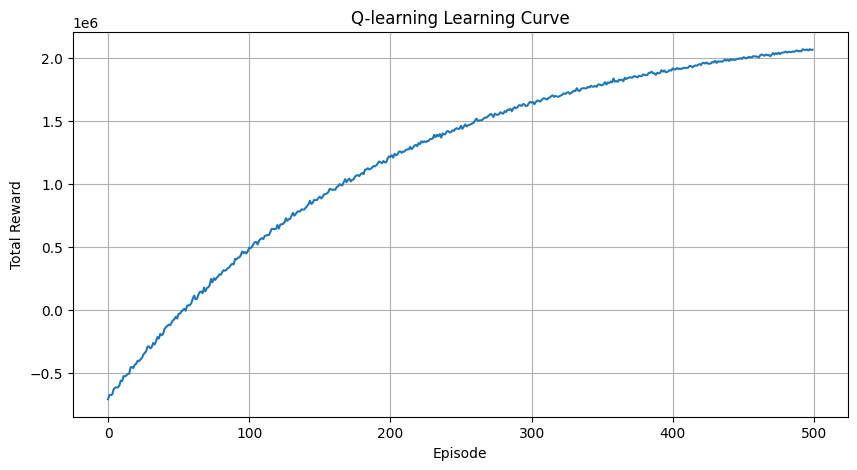


RL PERFORMANCE
F1: 0.0011
PR AUC: 0.7613

Classification Report:
              precision    recall  f1-score   support

           0       0.24      1.00      0.39      8190
           1       1.00      0.00      0.00     26107

    accuracy                           0.24     34297
   macro avg       0.62      0.50      0.19     34297
weighted avg       0.82      0.24      0.09     34297



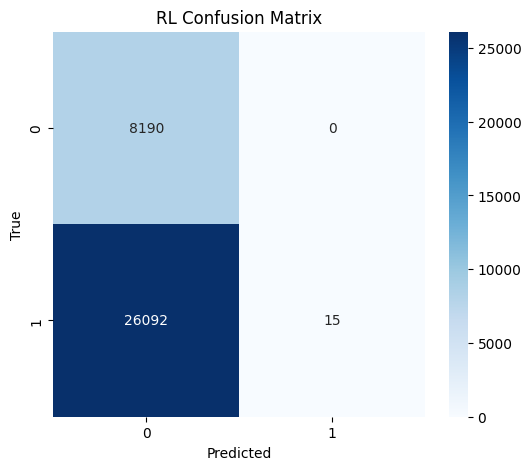


BASELINES
Random F1: 0.6042
Always approve F1: 0.0
Always review F1: 0.8644


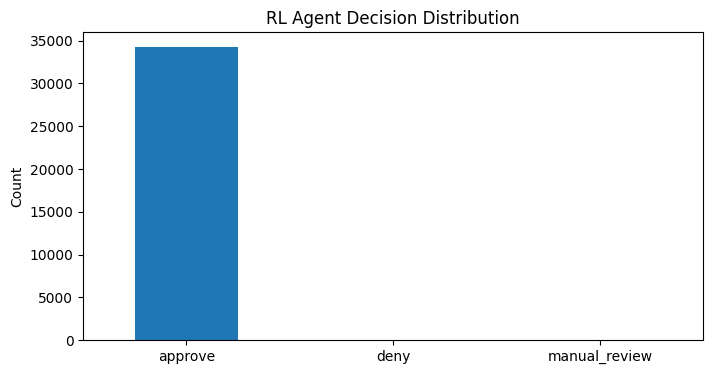


Average Business Reward: -68.9002


In [38]:
# ============================================================
# PART III — Reinforcement Learning for Claims Processing
# Improved Q-Learning (No Deep Learning)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.utils import resample


np.random.seed(cfg.RANDOM_STATE)

# ============================================================
# 1. STANDARDIZATION
# ============================================================

print("="*60)
print("STEP 1: Scaling features")
print("="*60)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test :", X_test_scaled.shape)


# ============================================================
# 2. PCA (25 components)
# ============================================================

print("\n" + "="*60)
print("STEP 2: PCA with 25 components")
print("="*60)

pca = PCA(
    n_components=60,
    random_state=cfg.RANDOM_STATE
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("New shape:", X_train_pca.shape)
print("Explained variance:",
      round(pca.explained_variance_ratio_.sum(),4))


# ============================================================
# 3. DISCRETIZE STATES
# ============================================================

print("\n" + "="*60)
print("STEP 3: Discretization")
print("="*60)

N_BINS = 5

disc = KBinsDiscretizer(
    n_bins=N_BINS,
    encode="ordinal",
    strategy="quantile"
)

X_train_disc = disc.fit_transform(X_train_pca).astype(int)
X_test_disc  = disc.transform(X_test_pca).astype(int)


# ============================================================
# 4. HASH STATE ENCODING
# ============================================================

def encode_state(x):
    return hash(tuple(x))

train_states = np.array(
    [encode_state(x) for x in X_train_disc]
)

test_states = np.array(
    [encode_state(x) for x in X_test_disc]
)

print("States encoded.")


# ============================================================
# 5. ACTIONS
# ============================================================

ACTIONS = {
    0: "approve",
    1: "request_docs",
    2: "manual_review",
    3: "deny"
}

N_ACTIONS = 4


# ============================================================
# 6. IMPROVED REWARD FUNCTION
# ============================================================

def reward_function(action, y):

    # class 1 = risky
    if y == 1:

        if action == 0:   # wrongly approve
            return -100

        elif action == 1:
            return 10

        elif action == 2:
            return 20

        elif action == 3:
            return 30


    # class 0 = safe
    else:

        if action == 0:
            return 30

        elif action == 1:
            return -5

        elif action == 2:
            return -10

        elif action == 3:
            return -20


# ============================================================
# 7. Q TABLE
# ============================================================

Q = defaultdict(
    lambda: np.zeros(N_ACTIONS)
)


# ============================================================
# 8. BALANCED SAMPLING
# ============================================================

minority = np.where(y_train_numeric == 1)[0]
majority = np.where(y_train_numeric == 0)[0]

weights = np.where(
    y_train_numeric == 1,
    1.0,
    0.5
)

balanced_idx = np.random.choice(
    np.arange(len(y_train_numeric)),
    size=len(y_train_numeric),
    replace=True,
    p=weights / weights.sum()
)

# ============================================================
# 9. TRAIN Q-LEARNING
# ============================================================

print("\n" + "="*60)
print("STEP 4: Training Q-learning")
print("="*60)

ALPHA = 0.10
GAMMA = 0.95

EPSILON = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.05

EPISODES = 500

reward_history = []


for ep in range(EPISODES):

    np.random.shuffle(balanced_idx)

    total_reward = 0

    for k, i in enumerate(balanced_idx):

        s = train_states[i]
        y = y_train_numeric[i]

        # epsilon-greedy
        if np.random.rand() < EPSILON:
            a = np.random.randint(N_ACTIONS)
        else:
            a = np.argmax(Q[s])

        r = reward_function(a, y)

        # sequential next state
        if k < len(balanced_idx)-1:
            s_next = train_states[
                balanced_idx[k+1]
            ]
        else:
            s_next = train_states[
                balanced_idx[0]
            ]

        # update
        Q[s][a] += ALPHA * (
            r
            + GAMMA*np.max(Q[s_next])
            - Q[s][a]
        )

        total_reward += r

    reward_history.append(total_reward)

    EPSILON = max(
        EPSILON_MIN,
        EPSILON * EPSILON_DECAY
    )

    if ep % 50 == 0:
        print(
            f"Episode {ep:3d} | "
            f"Reward={total_reward:8.0f} | "
            f"Epsilon={EPSILON:.3f}"
        )


# ============================================================
# 10. LEARNING CURVE
# ============================================================

plt.figure(figsize=(10,5))
plt.plot(reward_history)
plt.title("Q-learning Learning Curve")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid()
plt.show()


# ============================================================
# 11. TEST POLICY
# ============================================================

test_actions = np.array([
    np.argmax(Q[s])
    for s in test_states
])


# risky actions:
# manual_review or deny
y_pred_rl = np.isin(
    test_actions,
    [2, 3]
).astype(int)


# ============================================================
# 12. PR-AUC USING Q VALUES
# ============================================================

risk_scores = np.array([
    np.max(Q[s][1:])
    for s in test_states
])


# ============================================================
# 13. EVALUATION
# ============================================================

print("\n" + "="*60)
print("RL PERFORMANCE")
print("="*60)

f1 = f1_score(
    y_test_numeric,
    y_pred_rl
)

prauc = average_precision_score(
    y_test_numeric,
    risk_scores
)

print("F1:", round(f1,4))
print("PR AUC:", round(prauc,4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_numeric,
        y_pred_rl
    )
)


# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test_numeric,
    y_pred_rl
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("RL Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# ============================================================
# 15. BASELINES
# ============================================================

print("\n" + "="*60)
print("BASELINES")
print("="*60)

# random
rand_pred = np.random.randint(
    0, 2, len(y_test_numeric)
)

print(
    "Random F1:",
    round(
        f1_score(
            y_test_numeric,
            rand_pred
        ),4
    )
)

# always approve
approve_pred = np.zeros(
    len(y_test_numeric)
)

print(
    "Always approve F1:",
    round(
        f1_score(
            y_test_numeric,
            approve_pred
        ),4
    )
)

# always review
review_pred = np.ones(
    len(y_test_numeric)
)

print(
    "Always review F1:",
    round(
        f1_score(
            y_test_numeric,
            review_pred
        ),4
    )
)


# ============================================================
# 16. ACTION DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,4))

pd.Series(test_actions).map(
    ACTIONS
).value_counts().plot(
    kind="bar"
)

plt.title("RL Agent Decision Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


# ============================================================
# 17. BUSINESS REWARD
# ============================================================

avg_reward = np.mean([
    reward_function(a, y)
    for a, y in zip(
        test_actions,
        y_test_numeric
    )
])

print("\nAverage Business Reward:",
      round(avg_reward,4))